# Loading libraries

In [ ]:
pip install xgboost lightgbm catboost

In [ ]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression,Ridge,Lasso
from sklearn.model_selection import cross_val_score,GridSearchCV,RandomizedSearchCV,train_test_split
from sklearn.metrics import f1_score,accuracy_score,classification_report,confusion_matrix,roc_auc_score, auc,roc_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier,AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from mypipes import *

import warnings
warnings.filterwarnings('ignore') # ignore the warnings.


import matplotlib.pyplot as plt
import seaborn as sb
def report(results, n_top=3):
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results['rank_test_score'] == i)
        for candidate in candidates:
            print("Model with rank: {0}".format(i))
            print("Mean validation score: {0:.6f} (std: {1:.6f})".format(
                  results['mean_test_score'][candidate],
                  results['std_test_score'][candidate]))
            print("Parameters: {0}".format(results['params'][candidate]))
            print("")

def Threshold_Finder(Y_test,Y_predict):
    I = []
    roc_ = []
    for i in np.linspace(0.01,1,1000):
        Y_predict = Y_predict_prob[:,1] > i
        roc = f1_score(Y_test,Y_predict)
        I.append(i)
        roc_.append(roc)
    Temp = I[roc_.index(max(roc_))]
    return Temp

#  Loading the datasets

In [ ]:
train_data = r'paydayloan_collections.csv'
#test_data = r''

train_data = pd.read_csv(train_data)
#test_data = pd.read_csv(test_data)

In [ ]:
# Data Previews
train_data.transpose()


,0,1,2,3,4,5,6,7,8,9,...,29990,29991,29992,29993,29994,29995,29996,29997,29998,29999
payment,Success,Denied,Denied,Success,Success,Success,Success,Success,Denied,Denied,...,Success,Success,Denied,Success,Success,Success,Denied,Denied,Success,Success
var1,qw,qw,qw,wv,ma,kq,wv,qw,wv,qw,...,qw,wv,qw,wv,wv,qw,kq,kq,qw,qw
var2,hk,rv,zg,js,xn,py,py,rv,rv,rv,...,py,py,rv,bq,py,zg,bq,js,py,js
var3,3.11,3.35,4.15,6.23,1.28,-2.45,1.05,5.41,7.29,3.13,...,-3.2,7.75,4.82,2.2,2.51,3.85,3.32,2.98,-0.3,6.03
var4,16.06,11.18,29.19,15.7,20.71,22.45,23.02,17.92,26.83,34.21,...,7.38,26.77,26.04,-26.34,4.36,12.75,25.31,19.28,16.41,-6.99
var5,-4.6,-18.55,18.91,2.81,14.98,15.18,17.59,-14.59,33.92,22.55,...,40.39,45.77,14.51,18.82,53.03,47.62,15.9,16.2,22.8,-28.71
var6,22.34,6.68,16.4,4.46,11.19,-2.12,6.65,5.0,13.35,0.8,...,7.69,4.51,4.12,14.42,-0.73,3.34,10.96,-1.7,-9.99,11.82
var7,13.53,12.78,3.67,5.13,17.66,-8.24,-2.06,1.34,20.57,6.91,...,-5.24,6.97,12.07,2.44,14.0,17.22,10.13,9.45,26.89,4.71
var8,1.53,6.62,5.72,8.66,1.13,10.34,12.2,-8.54,4.46,11.18,...,7.09,15.35,11.31,4.12,15.72,7.0,10.32,-8.44,-1.1,5.0
var9,nv,nv,ch,ja,nv,ch,ch,ch,ch,ch,...,ch,ch,ch,ch,ch,ch,ch,ch,ch,ch


In [ ]:
# get information of Data
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 31 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   payment  30000 non-null  object 
 1   var1     30000 non-null  object 
 2   var2     30000 non-null  object 
 3   var3     30000 non-null  float64
 4   var4     30000 non-null  float64
 5   var5     30000 non-null  float64
 6   var6     30000 non-null  float64
 7   var7     30000 non-null  float64
 8   var8     30000 non-null  float64
 9   var9     30000 non-null  object 
 10  var10    30000 non-null  object 
 11  var11    30000 non-null  object 
 12  var12    30000 non-null  float64
 13  var13    30000 non-null  object 
 14  var14    30000 non-null  float64
 15  var15    30000 non-null  float64
 16  var16    30000 non-null  float64
 17  var17    30000 non-null  object 
 18  var18    30000 non-null  float64
 19  var19    30000 non-null  object 
 20  var20    30000 non-null  float64
 21  var21    300

In [ ]:
p1 = pdPipeline([
    ('columns_selection',VarSelector(['var1','var2','var9','var10','var11','var13','var17','var19','var23','var29'])),
    ('data_impute',DataFrameImputer()),
    ('get_dummy',get_dummies_Pipe())
])
temp = pd.DataFrame(data = p1.fit_transform(train_data),columns = p1.get_feature_names())

train_data = pd.concat([train_data,temp],axis = 1)

In [ ]:
Y_train = train_data['payment']
Y_train = pd.DataFrame(data = Y_train , columns = ['payment'] )
train_data.drop(columns = ['payment'],inplace = True)
X_train = train_data
X_train.drop(['var1','var2','var9','var10','var11','var13','var17','var19','var23','var29'],inplace = True,axis = 1)
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 62 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   var3      30000 non-null  float64
 1   var4      30000 non-null  float64
 2   var5      30000 non-null  float64
 3   var6      30000 non-null  float64
 4   var7      30000 non-null  float64
 5   var8      30000 non-null  float64
 6   var12     30000 non-null  float64
 7   var14     30000 non-null  float64
 8   var15     30000 non-null  float64
 9   var16     30000 non-null  float64
 10  var18     30000 non-null  float64
 11  var20     30000 non-null  float64
 12  var21     30000 non-null  float64
 13  var22     30000 non-null  float64
 14  var24     30000 non-null  float64
 15  var25     30000 non-null  float64
 16  var26     30000 non-null  float64
 17  var27     30000 non-null  float64
 18  var28     30000 non-null  float64
 19  var30     30000 non-null  float64
 20  var1_qw   30000 non-null  in

In [ ]:
Y_train

,payment
0,Success
1,Denied
2,Denied
3,Success
4,Success
...,...
29995,Success
29996,Denied
29997,Denied
29998,Success


In [ ]:
Y_train = (Y_train['payment'] == 'Success').astype(int)
Y_train

,payment
0,1
1,0
2,0
3,1
4,1
...,...
29995,1
29996,0
29997,0
29998,1


# Create train_test_spit (for 1 time validation)


In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X_train, Y_train, test_size=0.2, random_state=1)

# Logistic Regression

##  Fine a general model (default hyper parameter setting)


In [ ]:
LG_1 = LogisticRegression()
LG_1.fit(X_train,Y_train)

LogisticRegression()

In [ ]:
LG_1.coef_

array([[-2.99749747e-03, -1.28818922e-03,  7.18587114e-04,
         1.85339218e-03, -3.02381067e-02,  3.53588476e-06,
        -6.61731095e-04, -1.17360195e-02, -1.48890123e-03,
         3.88721597e-02, -1.08393794e-03,  3.67293583e-05,
        -1.52611394e-04,  5.93409400e-04,  4.63418595e-03,
        -1.79805874e-01, -2.32647722e-04, -4.60359014e-03,
         8.97188581e-03,  5.27923488e-04,  5.34348416e-02,
         9.06744114e-02, -5.22276686e-03,  6.09814224e-02,
        -9.31231792e-03,  3.85081407e-02, -3.13914726e-03,
         5.91548367e-02,  3.10702937e-02, -2.13620099e-02,
         1.62998868e-02,  9.61086961e-02,  7.91960610e-02,
         5.08362379e-02,  6.56861734e-02,  6.56391029e-02,
         1.82348489e-02,  2.08283549e-02,  1.64141826e-02,
         5.36548416e-02,  6.33671709e-02,  1.90575393e-02,
        -1.25551494e+00,  5.58212842e-01,  4.61476707e-01,
         3.01211070e-01,  6.49266949e-02,  1.48168039e-02,
         6.40696497e-02,  3.48010440e-02,  4.37761777e-0

In [ ]:
LG_1.intercept_

array([0.18151531])

In [ ]:
Y_predict = LG_1.predict(X_test)
Y_predict

array([0, 0, 0, ..., 1, 1, 1])

In [ ]:
confusion_matrix(Y_test,Y_predict)

array([[3417,  324],
       [ 534, 1725]])

In [ ]:
accuracy_score(Y_test,Y_predict)

0.857

In [ ]:
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.86      0.91      0.89      3741
           1       0.84      0.76      0.80      2259

    accuracy                           0.86      6000
   macro avg       0.85      0.84      0.84      6000
weighted avg       0.86      0.86      0.86      6000



In [ ]:
f1_score(Y_test,Y_predict)

0.8008356545961003

In [ ]:
Y_predict_prob = LG_1.predict_proba(X_test)
Y_predict_prob

array([[0.84955952, 0.15044048],
       [0.89009531, 0.10990469],
       [0.73465943, 0.26534057],
       ...,
       [0.2440662 , 0.7559338 ],
       [0.07885324, 0.92114676],
       [0.34634149, 0.65365851]])

In [ ]:
Y_predict = Y_predict_prob[:,1] > Threshold_Finder(Y_test,Y_predict)
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.89      0.88      0.89      3741
           1       0.81      0.83      0.82      2259

    accuracy                           0.86      6000
   macro avg       0.85      0.85      0.85      6000
weighted avg       0.86      0.86      0.86      6000



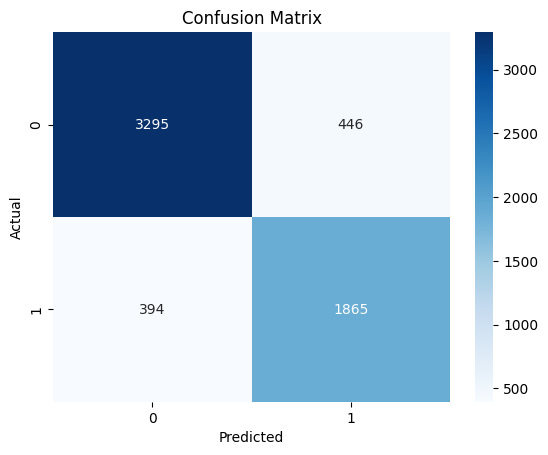

In [ ]:
cm = confusion_matrix(Y_test, Y_predict)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

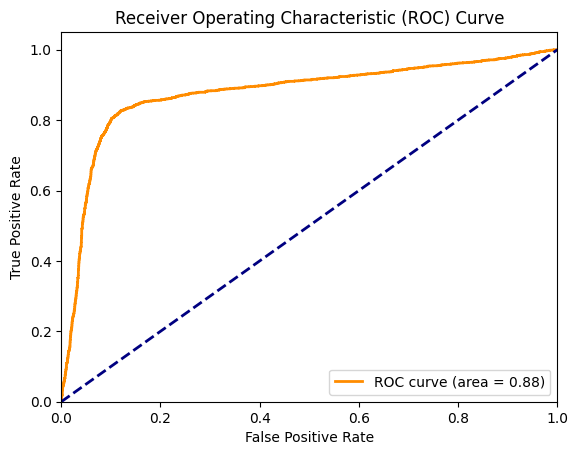

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(Y_test, LG_1.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

##  Hyper parameter with Cross validation (select best hyper parameter settings with multifold validations)


In [ ]:
param_grid = {'penalty':['l1', 'l2', 'elasticnet', None],
              'C':np.linspace(0.01,6,200),
              'class_weight':['balanced',None],
              'solver' : ['liblinear','saga']}

In [ ]:
Log_Reg_model = LogisticRegression()

Log_Reg_Random_Search = RandomizedSearchCV(Log_Reg_model,
                                          param_distributions = param_grid,
                                          cv = 5,
                                          n_iter = 25,
                                          scoring = 'roc_auc')



In [ ]:
Log_Reg_Random_Search.fit(X_train,Y_train)

RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=25,
                   param_distributions={'C': array([0.01      , 0.0401005 , 0.07020101, 0.10030151, 0.13040201,
       0.16050251, 0.19060302, 0.22070352, 0.25080402, 0.28090452,
       0.31100503, 0.34110553, 0.37120603, 0.40130653, 0.43140704,
       0.46150754, 0.49160804, 0.52170854, 0.55180905, 0.58190955,
       0.61201005, 0.64211055, 0.67221106, 0.70231...
       5.27758794, 5.30768844, 5.33778894, 5.36788945, 5.39798995,
       5.42809045, 5.45819095, 5.48829146, 5.51839196, 5.54849246,
       5.57859296, 5.60869347, 5.63879397, 5.66889447, 5.69899497,
       5.72909548, 5.75919598, 5.78929648, 5.81939698, 5.84949749,
       5.87959799, 5.90969849, 5.93979899, 5.9698995 , 6.        ]),
                                        'class_weight': ['balanced', None],
                                        'penalty': ['l1', 'l2', 'elasticnet',
                                                    None],
                                        'solver': ['liblinear', 'saga']},
                   scoring='roc_auc')

In [ ]:
Log_Reg_Random_Search.best_estimator_

LogisticRegression(C=np.float64(0.1605025125628141), penalty='l1',
                   solver='liblinear')

In [ ]:
# param_grid = {'penalty':['l1', 'l2', 'elasticnet', None],
#               'C':np.linspace(0.1,1,25),
#               'class_weight':['balanced',None],
#               'solver' : ['liblinear','saga']}
# Log_Reg_model = LogisticRegression()

# Log_Reg_Grid_Search = GridSearchCV(Log_Reg_model,
#                              param_grid = param_grid,
#                              cv = 5,
#                              scoring = 'roc_auc')
# Log_Reg_Grid_Search.fit(X_train,Y_train)

In [ ]:
  # Log_Reg_Grid_Search.best_estimator_

In [ ]:
# Log_Reg_model = Log_Reg_Grid_Search.best_estimator_

In [ ]:
Log_Reg_model.fit(X_train,Y_train)
# Y_predict = Log_Reg_model.predict(X_test)

In [ ]:
# confusion_matrix(Y_test,Y_predict)

In [ ]:
# print(classification_report(Y_test,Y_predict))

In [ ]:
# f1_score(Y_test,Y_predict)

In [ ]:
# Y_predict_prob = Log_Reg_model.predict_proba(X_test)

In [ ]:
# Threshold_Finder(Y_test,Y_predict)

In [ ]:
# Y_predict = Y_predict_prob[:,1] > Threshold_Finder(Y_test,Y_predict)
# print(classification_report(Y_test,Y_predict))

In [ ]:
# # ROC Curve
# fpr, tpr, thresholds = roc_curve(Y_test, Log_Reg_model.predict_proba(X_test)[:,1])
# roc_auc = auc(fpr, tpr)

# plt.figure()
# plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC) Curve')
# plt.legend(loc="lower right")
# plt.show()

In [ ]:
dtree_model = DecisionTreeClassifier()
dtree_model_cv_scores = cross_val_score(dtree_model,X_train,Y_train,cv=5,scoring='roc_auc')
dtree_model_cv_scores.mean() #uncontrolled decision tree's validation performance in auc is less than logistic

np.float64(0.7691384066012456)

In [ ]:
dtree_model.fit(X_train,Y_train)
Y_predict = dtree_model.predict(X_test)

In [ ]:
confusion_matrix(Y_test,Y_predict)

array([[3063,  678],
       [ 681, 1578]])

In [ ]:
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82      3741
           1       0.70      0.70      0.70      2259

    accuracy                           0.77      6000
   macro avg       0.76      0.76      0.76      6000
weighted avg       0.77      0.77      0.77      6000



In [ ]:
f1_score(Y_test,Y_predict)

0.6990033222591362

In [ ]:
Y_predict_prob = dtree_model.predict_proba(X_test)

In [ ]:
Threshold_Finder(Y_test,Y_predict)

np.float64(0.01)

In [ ]:
Y_predict = Y_predict_prob[:,1] > Threshold_Finder(Y_test,Y_predict)
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82      3741
           1       0.70      0.70      0.70      2259

    accuracy                           0.77      6000
   macro avg       0.76      0.76      0.76      6000
weighted avg       0.77      0.77      0.77      6000



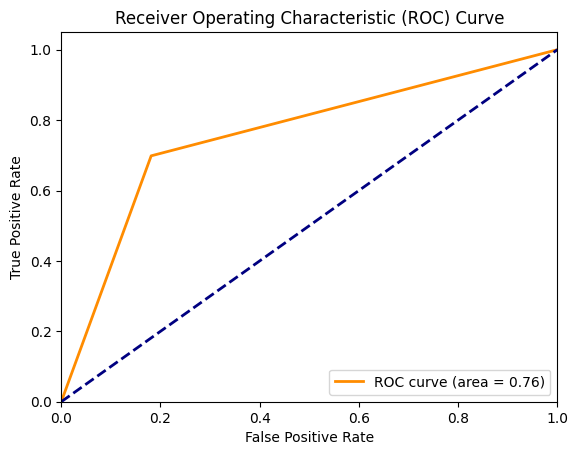

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(Y_test, dtree_model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
%%time
rf_model = RandomForestClassifier()
rf_model_cv_scores = cross_val_score(rf_model,X_train,Y_train,cv=5,scoring='roc_auc',n_jobs=-1)
rf_model_cv_scores.mean()
#slower processing compared to logistic, dtree
#better validation result

CPU times: user 394 ms, sys: 112 ms, total: 506 ms
Wall time: 42.3 s


np.float64(0.8855050181444527)

In [ ]:
rf_model.fit(X_train,Y_train)
Y_predict = rf_model.predict(X_test)

In [ ]:
confusion_matrix(Y_test,Y_predict)

array([[3418,  323],
       [ 505, 1754]])

In [ ]:
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.87      0.91      0.89      3741
           1       0.84      0.78      0.81      2259

    accuracy                           0.86      6000
   macro avg       0.86      0.85      0.85      6000
weighted avg       0.86      0.86      0.86      6000



In [ ]:
f1_score(Y_test,Y_predict)

0.809040590405904

In [ ]:
Y_predict_prob = rf_model.predict_proba(X_test)

In [ ]:
Threshold_Finder(Y_test,Y_predict_prob)

np.float64(0.4301801801801802)

In [ ]:
Y_predict = Y_predict_prob[:,1] > Threshold_Finder(Y_test,Y_predict_prob)
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      3741
           1       0.81      0.81      0.81      2259

    accuracy                           0.86      6000
   macro avg       0.85      0.85      0.85      6000
weighted avg       0.86      0.86      0.86      6000



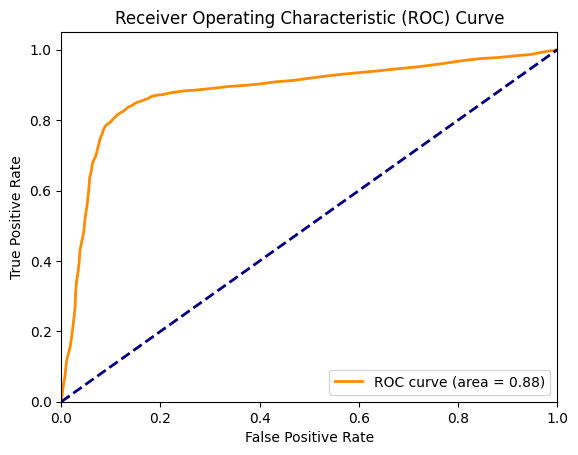

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(Y_test, rf_model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
%%time
et_model = ExtraTreesClassifier()
et_model_cv_scores = cross_val_score(et_model,X_train,Y_train,cv=5,scoring='roc_auc',n_jobs=-1)
et_model_cv_scores.mean()
#faster processing compared to randomforest
#better validation result than logistic, dtree

CPU times: user 215 ms, sys: 32.1 ms, total: 247 ms
Wall time: 19.5 s


np.float64(0.861909173669831)

In [ ]:
et_model.fit(X_train,Y_train)
Y_predict = et_model.predict(X_test)

In [ ]:
confusion_matrix(Y_test,Y_predict)

array([[3428,  313],
       [ 859, 1400]])

In [ ]:
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.80      0.92      0.85      3741
           1       0.82      0.62      0.70      2259

    accuracy                           0.80      6000
   macro avg       0.81      0.77      0.78      6000
weighted avg       0.81      0.80      0.80      6000



In [ ]:
f1_score(Y_test,Y_predict)

0.7049345417925479

In [ ]:
Y_predict_prob = et_model.predict_proba(X_test)

In [ ]:
Threshold_Finder(Y_test,Y_predict_prob)

np.float64(0.4202702702702703)

In [ ]:
Y_predict = Y_predict_prob[:,1] > Threshold_Finder(Y_test,Y_predict_prob)
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86      3741
           1       0.76      0.76      0.76      2259

    accuracy                           0.82      6000
   macro avg       0.81      0.81      0.81      6000
weighted avg       0.82      0.82      0.82      6000



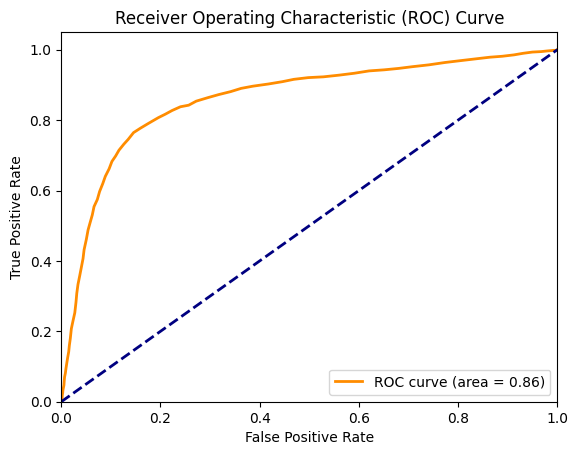

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(Y_test, et_model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
%%time
ada_model = AdaBoostClassifier()
ada_model_cv_scores = cross_val_score(ada_model,X_train,Y_train,cv=5,scoring='roc_auc',n_jobs=-1)
ada_model_cv_scores.mean()

CPU times: user 135 ms, sys: 39 ms, total: 174 ms
Wall time: 13 s


np.float64(0.8799612794886664)

In [ ]:
ada_model.fit(X_train,Y_train)
Y_predict = ada_model.predict(X_test)

In [ ]:
confusion_matrix(Y_test,Y_predict)

array([[3337,  404],
       [ 594, 1665]])

In [ ]:
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      3741
           1       0.80      0.74      0.77      2259

    accuracy                           0.83      6000
   macro avg       0.83      0.81      0.82      6000
weighted avg       0.83      0.83      0.83      6000



In [ ]:
f1_score(Y_test,Y_predict)

0.7694085027726433

In [ ]:
Y_predict_prob = ada_model.predict_proba(X_test)

In [ ]:
Threshold_Finder(Y_test,Y_predict_prob)

np.float64(0.456936936936937)

In [ ]:
Y_predict = Y_predict_prob[:,1] > Threshold_Finder(Y_test,Y_predict_prob)
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.89      0.84      0.87      3741
           1       0.76      0.83      0.79      2259

    accuracy                           0.84      6000
   macro avg       0.82      0.84      0.83      6000
weighted avg       0.84      0.84      0.84      6000



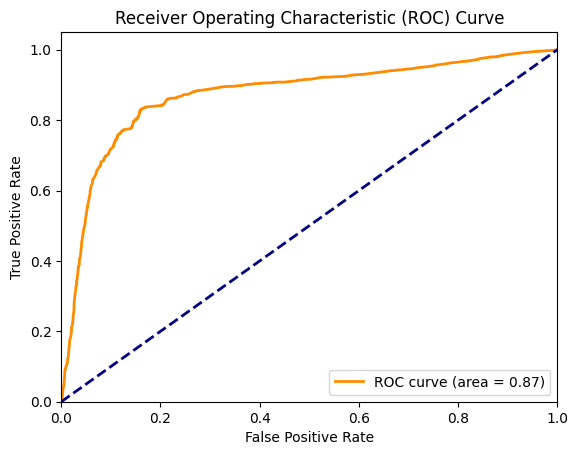

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(Y_test, ada_model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
%%time
gb_model = GradientBoostingClassifier()
gb_model_cv_scores = cross_val_score(gb_model,X_train,Y_train,cv=5,scoring='roc_auc',n_jobs=-1)
gb_model_cv_scores.mean()

CPU times: user 594 ms, sys: 121 ms, total: 715 ms
Wall time: 1min 9s


np.float64(0.8890017190009804)

In [ ]:
gb_model.fit(X_train,Y_train)
Y_predict = gb_model.predict(X_test)

In [ ]:
confusion_matrix(Y_test,Y_predict)

array([[3405,  336],
       [ 462, 1797]])

In [ ]:
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.88      0.91      0.90      3741
           1       0.84      0.80      0.82      2259

    accuracy                           0.87      6000
   macro avg       0.86      0.85      0.86      6000
weighted avg       0.87      0.87      0.87      6000



In [ ]:
f1_score(Y_test,Y_predict)

0.8183060109289617

In [ ]:
Y_predict_prob = gb_model.predict_proba(X_test)

In [ ]:
Threshold_Finder(Y_test,Y_predict_prob)

np.float64(0.4242342342342343)

In [ ]:
Y_predict = Y_predict_prob[:,1] > Threshold_Finder(Y_test,Y_predict_prob)
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.90      0.89      0.89      3741
           1       0.82      0.84      0.83      2259

    accuracy                           0.87      6000
   macro avg       0.86      0.86      0.86      6000
weighted avg       0.87      0.87      0.87      6000



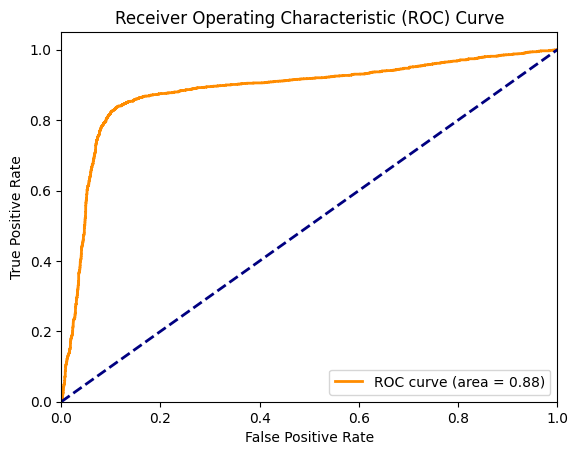

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(Y_test, gb_model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
%%time
xgb_model = XGBClassifier()
xgb_model_cv_scores = cross_val_score(xgb_model,X_train,Y_train,cv=5,scoring='roc_auc',n_jobs=-1)
xgb_model_cv_scores.mean()

CPU times: user 95.5 ms, sys: 22 ms, total: 118 ms
Wall time: 7.14 s


np.float64(0.8827757139960741)

In [ ]:
xgb_model.fit(X_train,Y_train)
Y_predict = xgb_model.predict(X_test)

In [ ]:
confusion_matrix(Y_test,Y_predict)

array([[3387,  354],
       [ 459, 1800]])

In [ ]:
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89      3741
           1       0.84      0.80      0.82      2259

    accuracy                           0.86      6000
   macro avg       0.86      0.85      0.85      6000
weighted avg       0.86      0.86      0.86      6000



In [ ]:
f1_score(Y_test,Y_predict)

0.8157715839564922

In [ ]:
Y_predict_prob = xgb_model.predict_proba(X_test)

In [ ]:
Threshold_Finder(Y_test,Y_predict_prob)

np.float64(0.4014414414414415)

In [ ]:
Y_predict = Y_predict_prob[:,1] > Threshold_Finder(Y_test,Y_predict_prob)
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      3741
           1       0.82      0.83      0.82      2259

    accuracy                           0.86      6000
   macro avg       0.85      0.86      0.86      6000
weighted avg       0.86      0.86      0.86      6000



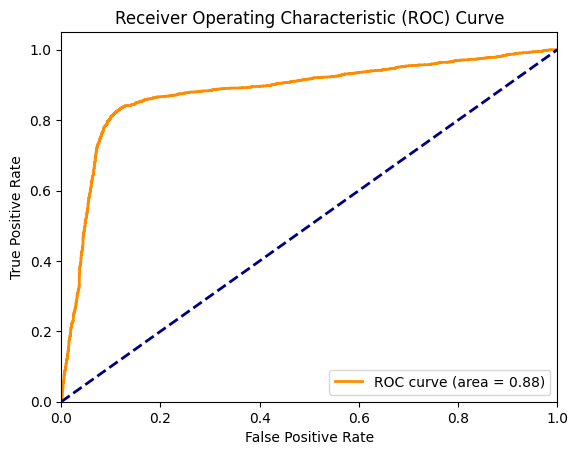

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(Y_test, xgb_model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
%%time
lgb_model = LGBMClassifier()
lgb_model_cv_scores = cross_val_score(lgb_model,X_train,Y_train,cv=5,scoring='roc_auc',n_jobs=-1)
lgb_model_cv_scores.mean()

CPU times: user 109 ms, sys: 19 ms, total: 128 ms
Wall time: 7.9 s


np.float64(0.8891084378389884)

In [ ]:
lgb_model.fit(X_train,Y_train)
Y_predict = lgb_model.predict(X_test)

[LightGBM] [Info] Number of positive: 8986, number of negative: 15014
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003035 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5184
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 62
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.374417 -> initscore=-0.513315
[LightGBM] [Info] Start training from score -0.513315


In [ ]:
confusion_matrix(Y_test,Y_predict)

array([[3411,  330],
       [ 416, 1843]])

In [ ]:
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      3741
           1       0.85      0.82      0.83      2259

    accuracy                           0.88      6000
   macro avg       0.87      0.86      0.87      6000
weighted avg       0.88      0.88      0.88      6000



In [ ]:
f1_score(Y_test,Y_predict)

0.8316787003610109

In [ ]:
Y_predict_prob = lgb_model.predict_proba(X_test)

In [ ]:
Threshold_Finder(Y_test,Y_predict_prob)

np.float64(0.41432432432432437)

In [ ]:
Y_predict = Y_predict_prob[:,1] > Threshold_Finder(Y_test,Y_predict_prob)
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      3741
           1       0.83      0.84      0.84      2259

    accuracy                           0.88      6000
   macro avg       0.87      0.87      0.87      6000
weighted avg       0.88      0.88      0.88      6000



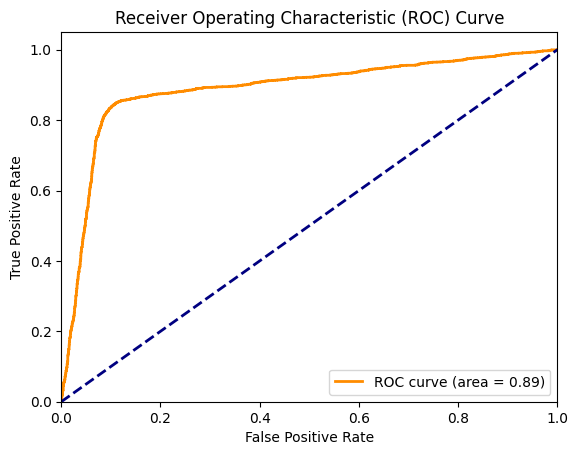

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(Y_test, lgb_model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
%%time
cb_model = CatBoostClassifier()
cb_model_cv_scores = cross_val_score(cb_model,X_train,Y_train,cv=5,scoring='roc_auc',n_jobs=-1)
cb_model_cv_scores.mean()

CPU times: user 778 ms, sys: 165 ms, total: 943 ms
Wall time: 1min 28s


np.float64(0.8909371352020707)

In [ ]:
cb_model.fit(X_train,Y_train)
Y_predict = cb_model.predict(X_test)

Learning rate set to 0.040021
0:	learn: 0.6675296	total: 67.9ms	remaining: 1m 7s
1:	learn: 0.6452212	total: 102ms	remaining: 51s
2:	learn: 0.6254495	total: 115ms	remaining: 38.1s
3:	learn: 0.6059213	total: 128ms	remaining: 31.8s
4:	learn: 0.5880209	total: 140ms	remaining: 27.9s
5:	learn: 0.5718522	total: 153ms	remaining: 25.4s
6:	learn: 0.5597428	total: 166ms	remaining: 23.5s
7:	learn: 0.5461153	total: 179ms	remaining: 22.2s
8:	learn: 0.5334705	total: 192ms	remaining: 21.2s
9:	learn: 0.5231118	total: 210ms	remaining: 20.8s
10:	learn: 0.5126780	total: 225ms	remaining: 20.2s
11:	learn: 0.5032010	total: 237ms	remaining: 19.5s
12:	learn: 0.4956384	total: 251ms	remaining: 19s
13:	learn: 0.4877502	total: 267ms	remaining: 18.8s
14:	learn: 0.4801944	total: 280ms	remaining: 18.4s
15:	learn: 0.4732024	total: 293ms	remaining: 18s
16:	learn: 0.4675784	total: 309ms	remaining: 17.8s
17:	learn: 0.4622923	total: 326ms	remaining: 17.8s
18:	learn: 0.4569810	total: 339ms	remaining: 17.5s
19:	learn: 0.452

In [ ]:
confusion_matrix(Y_test,Y_predict)

array([[3422,  319],
       [ 428, 1831]])

In [ ]:
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      3741
           1       0.85      0.81      0.83      2259

    accuracy                           0.88      6000
   macro avg       0.87      0.86      0.87      6000
weighted avg       0.87      0.88      0.87      6000



In [ ]:
f1_score(Y_test,Y_predict)

0.8305738262644591

In [ ]:
Y_predict_prob = cb_model.predict_proba(X_test)

In [ ]:
Threshold_Finder(Y_test,Y_predict_prob)

np.float64(0.4232432432432433)

In [ ]:
Y_predict = Y_predict_prob[:,1] > Threshold_Finder(Y_test,Y_predict_prob)
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      3741
           1       0.83      0.84      0.84      2259

    accuracy                           0.88      6000
   macro avg       0.87      0.87      0.87      6000
weighted avg       0.88      0.88      0.88      6000



In [ ]:
roc_auc_score(Y_test,Y_predict_prob[:,1])

np.float64(0.8837418747002546)

In [ ]:
accuracy_score(Y_test,Y_predict)

0.8763333333333333

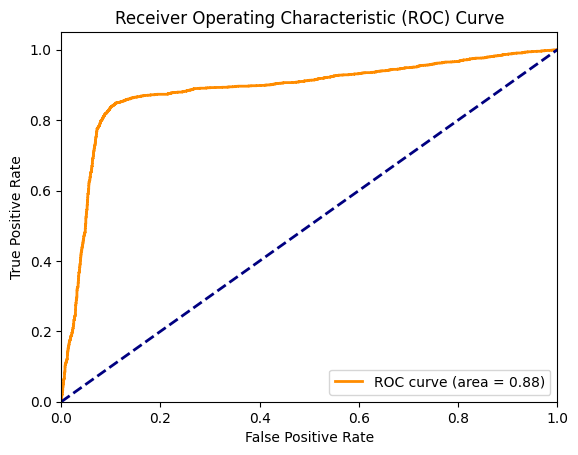

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(Y_test, cb_model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
%%time
dtree_clf_model = DecisionTreeClassifier()

dtree_clf_params = {
    'class_weight':[None,'balanced'],
    'criterion':['entropy','gini'],
    'max_depth':[None,5,10,15,20,30,50,70],
    'min_samples_leaf':[1,2,5,10,15,20],
    'min_samples_split':[2,5,10,15,20]
}

dtree_clf_random_search = RandomizedSearchCV(dtree_clf_model,param_distributions=dtree_clf_params,
                                             cv = 5, n_iter=10,scoring='roc_auc',n_jobs=-1)

dtree_clf_random_search.fit(X_train,Y_train)
dtree_clf_random_search.best_score_

CPU times: user 807 ms, sys: 78.1 ms, total: 885 ms
Wall time: 25.8 s


np.float64(0.8731998780676117)

In [ ]:
dtree_clf_model = dtree_clf_random_search.best_estimator_

In [ ]:
dtree_clf_model.fit(X_train,Y_train)
Y_predict = dtree_clf_model.predict(X_test)

In [ ]:
confusion_matrix(Y_test,Y_predict)

array([[3250,  491],
       [ 483, 1776]])

In [ ]:
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      3741
           1       0.78      0.79      0.78      2259

    accuracy                           0.84      6000
   macro avg       0.83      0.83      0.83      6000
weighted avg       0.84      0.84      0.84      6000



In [ ]:
f1_score(Y_test,Y_predict)

0.7847989394608926

In [ ]:
Y_predict_prob = dtree_clf_model.predict_proba(X_test)

In [ ]:
Threshold_Finder(Y_test,Y_predict_prob)

np.float64(0.28054054054054056)

In [ ]:
Y_predict = Y_predict_prob[:,1] > Threshold_Finder(Y_test,Y_predict_prob)
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.89      0.83      0.86      3741
           1       0.75      0.83      0.79      2259

    accuracy                           0.83      6000
   macro avg       0.82      0.83      0.83      6000
weighted avg       0.84      0.83      0.84      6000



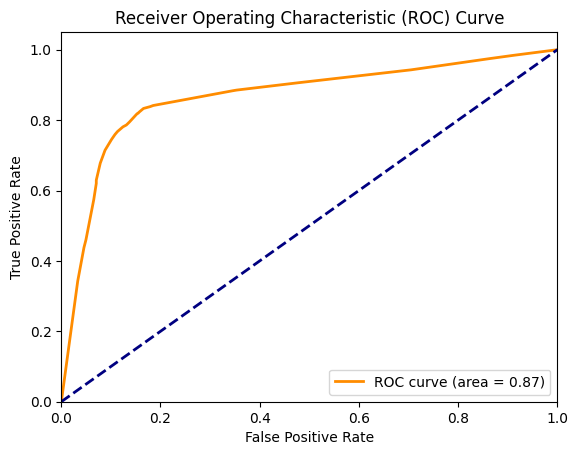

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(Y_test, dtree_clf_model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
%%time
rf_clf_model = RandomForestClassifier()

rf_clf_params = {
    'n_estimators':[100,200,300,500,700,1000], #number of individual decision trees to be created
    'max_features': [5,10,20,25,30,35], #how many features would be available at a split
    'bootstrap': [True, False], #should different data subsets go in or not
    'class_weight':[None,'balanced'],
    'criterion':['entropy','gini'],
    'max_depth':[None,5,10,15,20,30,50,70],
    'min_samples_leaf':[1,2,5,10,15,20],
    'min_samples_split':[2,5,10,15,20]
}

rf_clf_random_search = RandomizedSearchCV(rf_clf_model,param_distributions=rf_clf_params,
                                             cv = 5, n_jobs=-1, n_iter=7,scoring='roc_auc')

rf_clf_random_search.fit(X_train,Y_train)
rf_clf_random_search.best_score_

CPU times: user 4min 14s, sys: 4.8 s, total: 4min 19s
Wall time: 47min 1s


np.float64(0.889156292852942)

In [ ]:
rf_clf_model = rf_clf_random_search.best_estimator_

In [ ]:
rf_clf_model.fit(X_train,Y_train)
Y_predict = rf_clf_model.predict(X_test)

In [ ]:
confusion_matrix(Y_test,Y_predict)

array([[3322,  419],
       [ 375, 1884]])

In [ ]:
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.90      0.89      0.89      3741
           1       0.82      0.83      0.83      2259

    accuracy                           0.87      6000
   macro avg       0.86      0.86      0.86      6000
weighted avg       0.87      0.87      0.87      6000



In [ ]:
f1_score(Y_test,Y_predict)

0.8259535291538799

In [ ]:
Y_predict_prob = rf_clf_model.predict_proba(X_test)

In [ ]:
Threshold_Finder(Y_test,Y_predict_prob)

np.float64(0.5808108108108109)

In [ ]:
Y_predict = Y_predict_prob[:,1] > Threshold_Finder(Y_test,Y_predict_prob)
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      3741
           1       0.84      0.82      0.83      2259

    accuracy                           0.87      6000
   macro avg       0.87      0.86      0.86      6000
weighted avg       0.87      0.87      0.87      6000



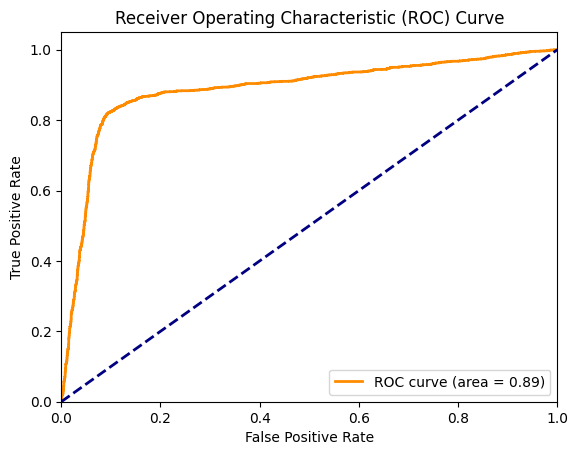

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(Y_test, rf_clf_model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
%%time
cb_clf_model = CatBoostClassifier()

cb_clf_params = {
   'n_estimators':[50,100,200,500,700],
   'learning_rate': [0.01,.05,0.1,0.4,0.8,1],
   'max_depth':[1,2,3,4,5,6],
   'subsample':[0.5,0.8,1],
   'colsample_bylevel':[i/10.0 for i in range(5,10)],
   'l2_leaf_reg':[1e-5, 1e-2, 0.1, 1, 100]
}

cb_clf_random_search = RandomizedSearchCV(cb_clf_model,param_distributions=cb_clf_params,
                                             cv = 5, n_iter=2,scoring='roc_auc',n_jobs=-1)



CPU times: user 156 µs, sys: 0 ns, total: 156 µs
Wall time: 160 µs


In [ ]:
cb_clf_random_search.fit(X_train,Y_train)
cb_clf_random_search.best_score_

0:	learn: 0.6854727	total: 54.4ms	remaining: 2.67s
1:	learn: 0.6594691	total: 61.1ms	remaining: 1.47s
2:	learn: 0.6535002	total: 67.6ms	remaining: 1.06s
3:	learn: 0.6308239	total: 90ms	remaining: 1.03s
4:	learn: 0.6122516	total: 98.5ms	remaining: 886ms
5:	learn: 0.5949759	total: 105ms	remaining: 772ms
6:	learn: 0.5790236	total: 112ms	remaining: 687ms
7:	learn: 0.5640559	total: 120ms	remaining: 630ms
8:	learn: 0.5509001	total: 127ms	remaining: 577ms
9:	learn: 0.5378885	total: 133ms	remaining: 533ms
10:	learn: 0.5286640	total: 140ms	remaining: 495ms
11:	learn: 0.5187404	total: 146ms	remaining: 462ms
12:	learn: 0.5092673	total: 155ms	remaining: 442ms
13:	learn: 0.5033960	total: 161ms	remaining: 415ms
14:	learn: 0.4957858	total: 167ms	remaining: 391ms
15:	learn: 0.4941361	total: 174ms	remaining: 369ms
16:	learn: 0.4865710	total: 180ms	remaining: 349ms
17:	learn: 0.4798514	total: 186ms	remaining: 331ms
18:	learn: 0.4750459	total: 192ms	remaining: 314ms
19:	learn: 0.4700999	total: 199ms	rema

np.float64(0.8834809159634563)

In [ ]:
cb_clf_model = cb_clf_random_search.best_estimator_

In [ ]:
cb_clf_model.fit(X_train,Y_train)
Y_predict_prob = cb_clf_model.predict_proba(X_test)
Y_predict = cb_clf_model.predict(X_test)

0:	learn: 0.6854727	total: 6.92ms	remaining: 339ms
1:	learn: 0.6594691	total: 13.4ms	remaining: 321ms
2:	learn: 0.6535002	total: 19.8ms	remaining: 310ms
3:	learn: 0.6308239	total: 26.5ms	remaining: 304ms
4:	learn: 0.6122516	total: 32.8ms	remaining: 295ms
5:	learn: 0.5949759	total: 39.3ms	remaining: 288ms
6:	learn: 0.5790236	total: 45.7ms	remaining: 280ms
7:	learn: 0.5640559	total: 52.3ms	remaining: 274ms
8:	learn: 0.5509001	total: 59ms	remaining: 269ms
9:	learn: 0.5378885	total: 65.5ms	remaining: 262ms
10:	learn: 0.5286640	total: 74ms	remaining: 262ms
11:	learn: 0.5187404	total: 80.1ms	remaining: 254ms
12:	learn: 0.5092673	total: 86.6ms	remaining: 246ms
13:	learn: 0.5033960	total: 92.5ms	remaining: 238ms
14:	learn: 0.4957858	total: 98.6ms	remaining: 230ms
15:	learn: 0.4941361	total: 104ms	remaining: 222ms
16:	learn: 0.4865710	total: 110ms	remaining: 214ms
17:	learn: 0.4798514	total: 116ms	remaining: 207ms
18:	learn: 0.4750459	total: 123ms	remaining: 200ms
19:	learn: 0.4700999	total: 12

In [ ]:
roc_auc_score(Y_test,Y_predict_prob[:,1])

np.float64(0.8755243068830738)

In [ ]:
confusion_matrix(Y_test,Y_predict)

array([[3362,  379],
       [ 561, 1698]])

In [ ]:
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      3741
           1       0.82      0.75      0.78      2259

    accuracy                           0.84      6000
   macro avg       0.84      0.83      0.83      6000
weighted avg       0.84      0.84      0.84      6000



In [ ]:
f1_score(Y_test,Y_predict)

0.783210332103321

In [ ]:
Y_predict_prob = cb_clf_model.predict_proba(X_test)

In [ ]:
Threshold_Finder(Y_test,Y_predict_prob)

np.float64(0.38162162162162167)

In [ ]:
Y_predict = Y_predict_prob[:,1] > Threshold_Finder(Y_test,Y_predict_prob)
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

           0       0.90      0.86      0.87      3741
           1       0.78      0.83      0.80      2259

    accuracy                           0.85      6000
   macro avg       0.84      0.84      0.84      6000
weighted avg       0.85      0.85      0.85      6000



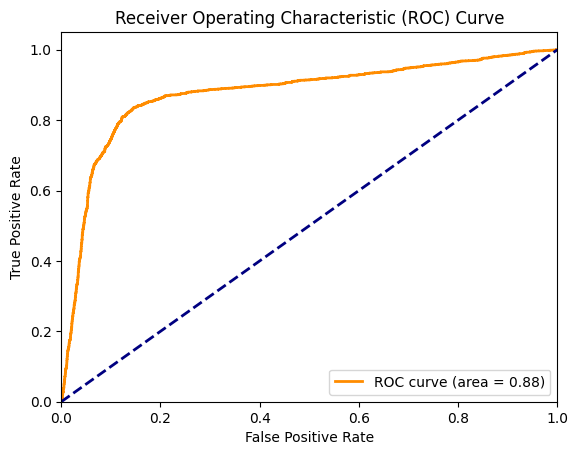

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(Y_test, cb_clf_model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

#### Bases on the above Model performance.
#### We can Consider lgb_model, cb_model Model for predicting whether Person will default on the payday loan.
